## When I learned about linear regression, it instantly reminded me of CAPM I learned while studying finance.
## In order to model CAPM via linear regression, and hence calculate and analyze beta, underlying economics assumptions must be defined.
### [Assumptions CAPM is based on:](https://www.cambridge.org/ch/files/9813/6698/2509/chpt3prt3capm.pdf)
* ### Financial markets are perfect and competitive:
    * ### no taxes or transaction costs, all assets are marketable and perfectly divisible, no limitations on short selling and risk-free borrowing and lending
    * ### large numbers of buyers and sellers, none large enough to individually influence prices, all information simultaneously and costlessly available to all investors
* ### Investors
    * ### maximize expected utility of their end wealth by choosing investments based on their mean-variance characteristics over a single holding period
    * ### have homogeneous expectations with respect to returns (i.e. they observe same efficient frontier)

### CAPM is a financial model that describes the relationship between an investment's risk and its expected return. It helps investors understand how much extra return they should expect for taking on more systematic (market-wide) risk, using the formula:
### Expected Return = Risk-Free Rate + Beta * (Expected Market Return - Risk-Free Rate).

#### $ER_i = R_f + \beta_i(ER_m - R_f)$

#### $ER_i$ = expected return of the investment

#### $R_f$ = risk-free rate

#### $\beta_i$ = beta of the investment

#### $ER_m$ = expected return of the market

#### $ER_m - R_f$ = market risk premium

### As FARM.MI is on the Italian stock exchange, I chose:
 * ### *Financial Times Stock Exchange Milano Indice di Borsa* (FTSEMIB.MI on Yahoo Finance) for calculating the expected return of the market returns
 * ### *H-Farm S.p.A.* (FARM.MI on Yahoo Finance) for calculating its expected return
 * ### *10-year Italian government bonds* (BTP10.MI on Yahoo Finance) as a risk-free stock

### Let's download and display the *FTSEMIB.MI* and *H-Farm S.p.A.* data from Yahoo Finance for the last 5 years

In [94]:
import yfinance as yf
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

In [95]:
end_date = dt.datetime(2026, 2, 26, 17, 50, 46, 826868)  # the end date is today 26/02/2026
start_date = dt.date(end_date.year - 5, end_date.month, end_date.day)  # the start date is a day 5 years ago

### Let's create a dataframe with returns of the market and the asset

In [96]:
df = yf.download(["FTSEMIB.MI", "FARM.MI", "BTP10.MI"], start=start_date, end=end_date)
df = df['Close']

[*********************100%***********************]  3 of 3 completed


In [97]:
returns = df.pct_change().fillna(0)

In [98]:
returns

Ticker,BTP10.MI,FARM.MI,FTSEMIB.MI
Date,,,
2021-02-26,0.000000,0.000000,0.000000
2021-03-01,0.000000,0.016260,0.018206
2021-03-02,0.000000,-0.016000,-0.007780
2021-03-03,0.000000,0.000000,-0.001603
2021-03-04,0.000000,0.000000,0.001996
...,...,...,...
2026-02-20,0.000191,-0.031830,0.014827
2026-02-23,0.001906,-0.008219,0.004863
2026-02-24,0.000634,0.011050,-0.001006


### Now let's build a linear regression:

#### $ER_i = R_f + \beta_i(ER_m - R_f)$

#### $ER_i$ = expected return of the investment

#### $R_f$ = risk-free rate

#### $\beta_i$ = beta of the investment

#### $ER_m$ = expected return of the market

#### $ER_m - R_f$ = market risk premium

In [99]:
market_risk_premium = returns["FTSEMIB.MI"] - returns["BTP10.MI"]  # x-axis

In [100]:
farm_mi_returns = returns["FARM.MI"]  # y-axis
risk_free_returns = returns["BTP10.MI"]  # y-intercept

In [101]:
market_risk_premium

Date
2021-02-26    0.000000
2021-03-01    0.018206
2021-03-02   -0.007780
2021-03-03   -0.001603
2021-03-04    0.001996
                ...   
2026-02-20    0.014637
2026-02-23    0.002957
2026-02-24   -0.001640
2026-02-25    0.010090
2026-02-26    0.004668
Length: 1272, dtype: float64

### I will use mean absolute error (MSE) to calculate loss to move closer to the outliers.

#### $MSE = \frac{1}{N} \sum_{j = 1}^{N}\text{(actual value - predicted value)} ^ 2$

### Let's calculate the slope of the tangent to the loss function to change the beta using derivative:

$$\frac{\partial MSE}{\partial \beta} = \frac{2}{N} \sum_{j=1}^{N} - (ER_m - R_f) \cdot (ER_i - R_f - \beta(ER_m - R_f))$$

### We will change $\beta$ according to the next formula:

$ \beta_{new} = \beta_{old} - \text{learning rate} * \beta_{slope}$

In [102]:
learning_rate = 0.1
n = len(market_risk_premium)
beta = 0.0

excess_return_stock = farm_mi_returns - risk_free_returns

for i in range(50000):
    prediction = beta * market_risk_premium
    gradient = (-2 / n) * (market_risk_premium * (excess_return_stock - prediction)).sum()
    beta = beta - learning_rate * gradient

print(f"Final beta for H-Farm S.p.A.: {beta:.4f}")

Final beta for H-Farm S.p.A.: 0.2362


In [103]:
excess_return_stock_mean = np.mean(excess_return_stock)
ss_res = np.sum((excess_return_stock - (beta * market_risk_premium)) ** 2)
ss_tot = np.sum((excess_return_stock - excess_return_stock_mean) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"R-Squared: {r_squared:.4f}")

R-Squared: 0.0164


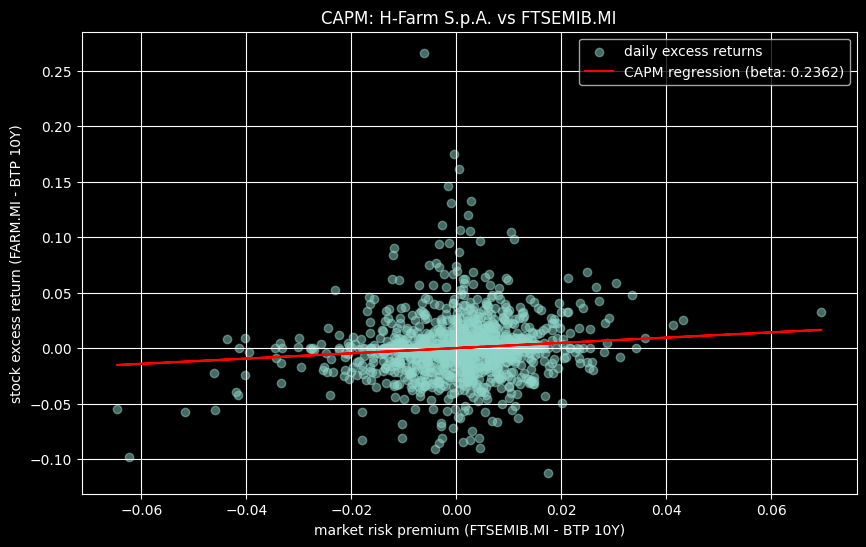

In [106]:
plt.figure(figsize=(10, 6))
plt.scatter(market_risk_premium, excess_return_stock, alpha=0.5, label='daily excess returns')
plt.plot(market_risk_premium, beta * market_risk_premium, color='red', label=f'CAPM regression (beta: {beta:.4f})')
plt.title('CAPM: H-Farm S.p.A. vs FTSEMIB.MI')
plt.xlabel('market risk premium (FTSEMIB.MI - BTP 10Y)')
plt.ylabel('stock excess return (FARM.MI - BTP 10Y)')
plt.legend()
plt.grid(True)
plt.show()

## $\beta = 0.2362 < 1$. Thus, the H-Farm S.p.A. stocks are less volatile that the market.